> Alzheimer's Disease Multiclass Images Dataset  
https://www.kaggle.com/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

tf.config.optimizer.set_jit(True)
mixed_precision.set_global_policy('mixed_float16')

print("Num GPUs Available:", len(gpus))
print("Mixed Precision Policy:", mixed_precision.global_policy())

I0000 00:00:1776105231.386248    1375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776105234.174548    1375 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776105284.200832    1375 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Num GPUs Available: 1
Mixed Precision Policy: <DTypePolicy "mixed_float16">


In [3]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model

In [4]:
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'datasets/alzheimer/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
 )

test_dataset = tf.keras.utils.image_dataset_from_directory(
    'datasets/alzheimer/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

Found 10240 files belonging to 4 classes.


I0000 00:00:1776105329.496037    1375 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1279 files belonging to 4 classes.


In [5]:
def normalize(x, y):
    return tf.cast(x, tf.float32), y

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(normalize, num_parallel_calls=AUTOTUNE).shuffle(256).prefetch(AUTOTUNE)
test_dataset = test_dataset.map(normalize, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

I0000 00:00:1776105349.906979    1834 shuffle_dataset_op.cc:453] ShuffleDatasetV3:17: Filling up shuffle buffer (this may take a while): 216 of 256
I0000 00:00:1776105350.528296    1834 shuffle_dataset_op.cc:483] Shuffle buffer filled.


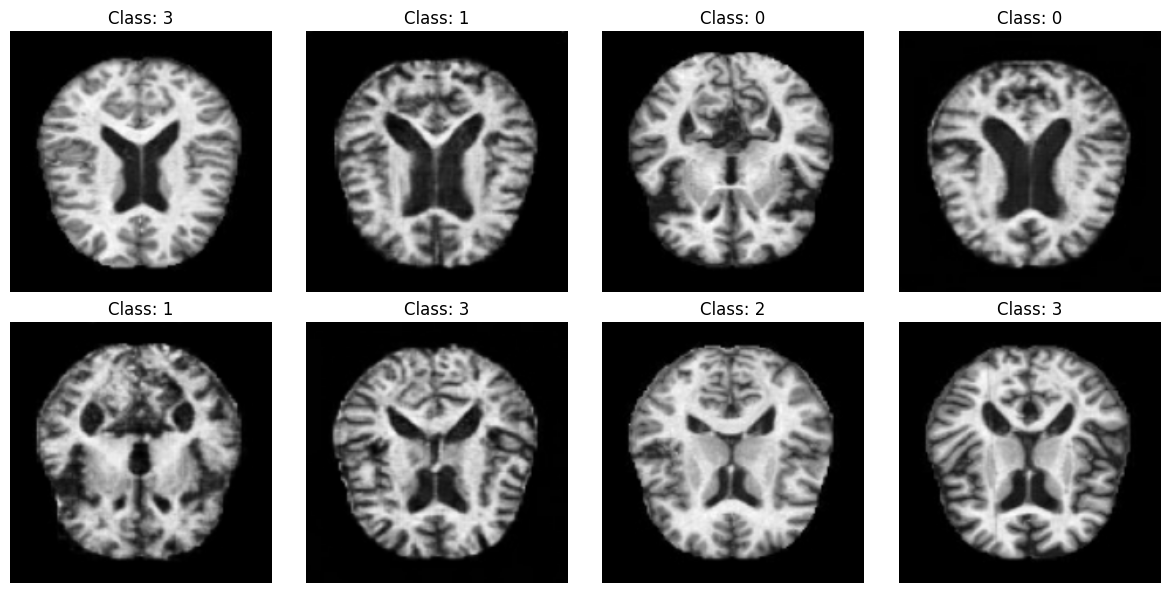

W0000 00:00:1776105352.052670    1375 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777472 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


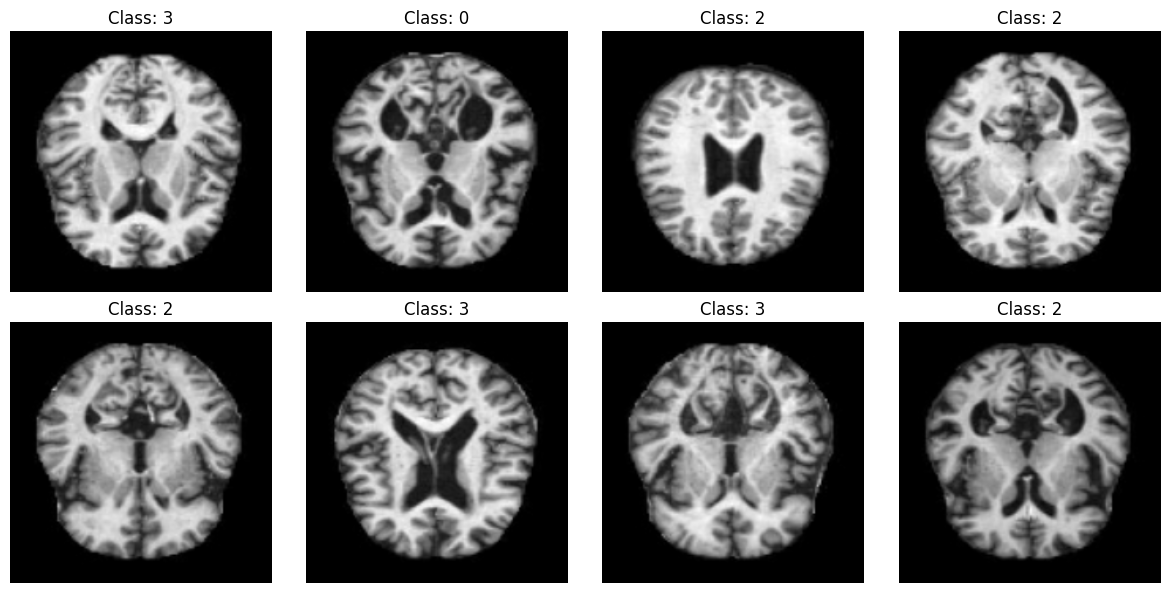

In [6]:
import math

def plot_images(images, labels):
    num_images = images.shape[0]
    num_rows = int(math.ceil(num_images / 4))
    fig, axes = plt.subplots(num_rows, 4, figsize=(12, 3 * num_rows))
    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(num_images):
        row = i // 4
        col = i % 4
        image_to_show = images[i]
        if image_to_show.dtype != np.uint8:
            image_to_show = np.clip(image_to_show / 255.0, 0.0, 1.0)
        axes[row, col].imshow(image_to_show)
        axes[row, col].set_title(f"Class: {np.argmax(labels[i])}")
        axes[row, col].axis('off')
    for i in range(num_images, num_rows * 4):
        row = i // 4
        col = i % 4
        axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

for images, labels in train_dataset.take(1):
    plot_images(images.numpy()[:8], labels.numpy()[:8])

for images, labels in test_dataset.take(1):
    plot_images(images.numpy()[:8], labels.numpy()[:8])

In [7]:
# model = Sequential([
#     Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
#     Conv2D(64, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(128, (3, 3), activation='relu', padding='same'),
#     Conv2D(128, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     Conv2D(256, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     Conv2D(512, (3, 3), activation='relu', padding='same'),
#     MaxPooling2D((2, 2), strides=2),

#     Flatten(),
#     Dense(4096, activation='relu'),
#     Dense(4096, activation='relu'),
#     Dense(4, activation='softmax')
# ])

In [8]:
# model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
# history = model.fit(train_dataset, epochs=25, validation_data=test_dataset, verbose=1)

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

vgg16_inputs = Input(shape=(224, 224, 3))
vgg16_x = vgg16_preprocess(vgg16_inputs)
vgg16_base_model = VGG16(weights='imagenet', include_top=False, input_tensor=vgg16_x)
for layer in vgg16_base_model.layers:
    layer.trainable = False

num_classes = 4
vgg16_x = GlobalAveragePooling2D()(vgg16_base_model.output)
vgg16_x = Dense(256, activation='relu')(vgg16_x)
vgg16_x = Dropout(0.3)(vgg16_x)
vgg16_predictions = Dense(num_classes, activation='softmax', dtype='float32')(vgg16_x)

vgg16_model = Model(inputs=vgg16_inputs, outputs=vgg16_predictions)
vgg16_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ add[0][0]         │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
vgg16_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
vgg16_history = vgg16_model.fit(train_dataset, epochs=15, validation_data=test_dataset, verbose=1)

Epoch 1/15


I0000 00:00:1776102400.455143   26719 service.cc:153] XLA service 0x764ed40349d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776102400.455285   26719 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776102400.690057   26719 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776102401.491467   26719 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776102401.603678   26719 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2514__.80
I0000 00:00:1776102417.721813   26719 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


640/640 ━━━━━━━━━━━━━━━━━━━━ 51s 44ms/step - accuracy: 0.5262 - loss: 1.4244 - val_accuracy: 0.5356 - val_loss: 0.9760
Epoch 2/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.6982 - loss: 0.6965 - val_accuracy: 0.6005 - val_loss: 0.8594
Epoch 3/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7483 - loss: 0.5872 - val_accuracy: 0.6208 - val_loss: 0.8206
Epoch 4/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7774 - loss: 0.5245 - val_accuracy: 0.6529 - val_loss: 0.7636
Epoch 5/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7979 - loss: 0.4814 - val_accuracy: 0.6701 - val_loss: 0.7456
Epoch 6/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8082 - loss: 0.4485 - val_accuracy: 0.6685 - val_loss: 0.7320
Epoch 7/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8197 - loss: 0.4177 - val_accuracy: 0.6974 - val_loss: 0.6786
Epoch 8/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8405 - loss: 0.3867 - val_accurac

In [13]:
vgg16_model.save('outputs/alzheimer/vgg16-alzheimer-vgg16-model.keras')

In [14]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

inception_inputs = Input(shape=(224, 224, 3))
inception_x = inception_preprocess(inception_inputs)
inception_base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=inception_x)
for layer in inception_base_model.layers:
    layer.trainable = False

num_classes = 4
inception_x = GlobalAveragePooling2D()(inception_base_model.output)
inception_x = Dense(256, activation='relu')(inception_x)
inception_x = Dropout(0.4)(inception_x)
inception_predictions = Dense(num_classes, activation='softmax', dtype='float32')(inception_x)

inception_model = Model(inputs=inception_inputs, outputs=inception_predictions)
inception_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ subtract[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][

 Total params: 22,328,356 (85.18 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [15]:
inception_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [16]:
inception_model_history = inception_model.fit(train_dataset, epochs=15, validation_data=test_dataset, verbose=1)

Epoch 1/15


W0000 00:00:1776102770.555736   28634 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1776102775.127020   26720 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_60514__.226


640/640 ━━━━━━━━━━━━━━━━━━━━ 112s 87ms/step - accuracy: 0.6106 - loss: 0.9029 - val_accuracy: 0.5653 - val_loss: 0.9343
Epoch 2/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7094 - loss: 0.6609 - val_accuracy: 0.5598 - val_loss: 0.8979
Epoch 3/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7377 - loss: 0.5923 - val_accuracy: 0.5739 - val_loss: 0.8727
Epoch 4/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7655 - loss: 0.5414 - val_accuracy: 0.5841 - val_loss: 0.8371
Epoch 5/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7784 - loss: 0.5115 - val_accuracy: 0.6044 - val_loss: 0.7992
Epoch 6/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.7898 - loss: 0.4878 - val_accuracy: 0.6091 - val_loss: 0.8216
Epoch 7/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8003 - loss: 0.4620 - val_accuracy: 0.6208 - val_loss: 0.7846
Epoch 8/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8124 - loss: 0.4367 - val_accura

In [17]:
inception_model.save('outputs/alzheimer/inception-alzheimer-inception-model.keras')

In [18]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

resnet_inputs = Input(shape=(224, 224, 3))
resnet_x = resnet_preprocess(resnet_inputs)
resnet_base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=resnet_x)
for layer in resnet_base_model.layers:
    layer.trainable = False

num_classes = 4
resnet_x = GlobalAveragePooling2D()(resnet_base_model.output)
resnet_x = Dense(256, activation='relu')(resnet_x)
resnet_x = Dropout(0.4)(resnet_x)
resnet_predictions = Dense(num_classes, activation='softmax', dtype='float32')(resnet_x)

resnet_model = Model(inputs=resnet_inputs, outputs=resnet_predictions)
resnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ add_1[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
resnet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
resnet_model_history = resnet_model.fit(train_dataset, epochs=15, validation_data=test_dataset, verbose=1)

Epoch 1/15


W0000 00:00:1776103139.270336   30957 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1776103143.146451   26719 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121279__.195


640/640 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.6419 - loss: 0.8590 - val_accuracy: 0.5778 - val_loss: 0.9116
Epoch 2/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7407 - loss: 0.6027 - val_accuracy: 0.5801 - val_loss: 0.8636
Epoch 3/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7629 - loss: 0.5371 - val_accuracy: 0.6099 - val_loss: 0.8319
Epoch 4/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.7849 - loss: 0.4975 - val_accuracy: 0.6349 - val_loss: 0.7673
Epoch 5/15
  3/640 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8264 - loss: 0.4742

W0000 00:00:1776103247.579599   30957 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8018 - loss: 0.4620 - val_accuracy: 0.6568 - val_loss: 0.7514
Epoch 6/15
  3/640 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.8646 - loss: 0.4196

...

640/640 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8542 - loss: 0.3502 - val_accuracy: 0.7217 - val_loss: 0.6323
Epoch 12/15
  3/640 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.8438 - loss: 0.3630

W0000 00:00:1776103368.373624   30957 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


640/640 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8614 - loss: 0.3305 - val_accuracy: 0.7349 - val_loss: 0.6141
Epoch 13/15
  3/640 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8750 - loss: 0.3714

W0000 00:00:1776103385.866147   30957 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


640/640 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8726 - loss: 0.3150 - val_accuracy: 0.6912 - val_loss: 0.6919
Epoch 14/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8738 - loss: 0.3075 - val_accuracy: 0.7404 - val_loss: 0.5868
Epoch 15/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8818 - loss: 0.2901 - val_accuracy: 0.7443 - val_loss: 0.5758


In [21]:
resnet_model.save('outputs/alzheimer/resnet-alzheimer-resnet-model.keras')

In [22]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

efficientnet_inputs = Input(shape=(224, 224, 3))
efficientnet_x = efficientnet_preprocess(efficientnet_inputs)
efficientnet_base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=efficientnet_x)
for layer in efficientnet_base_model.layers:
    layer.trainable = False

num_classes = 4
efficientnet_x = GlobalAveragePooling2D()(efficientnet_base_model.output)
efficientnet_x = Dense(256, activation='relu')(efficientnet_x)
efficientnet_x = Dropout(0.4)(efficientnet_x)
efficientnet_predictions = Dense(num_classes, activation='softmax', dtype='float32')(efficientnet_x)

efficientnet_model = Model(inputs=efficientnet_inputs, outputs=efficientnet_predictions)
efficientnet_model.summary()

E0000 00:00:1776103436.757838   26355 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
efficientnet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
efficientnet_model_history = efficientnet_model.fit(train_dataset, epochs=15, validation_data=test_dataset, verbose=1)

Epoch 1/15


W0000 00:00:1776103458.327211   32653 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1776103464.174966   26718 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_186465__.264


640/640 ━━━━━━━━━━━━━━━━━━━━ 178s 125ms/step - accuracy: 0.6156 - loss: 0.8903 - val_accuracy: 0.5356 - val_loss: 0.9701
Epoch 2/15
  2/640 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.3906 - loss: 0.9168

W0000 00:00:1776103621.505484   32653 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


640/640 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.6998 - loss: 0.6909 - val_accuracy: 0.5629 - val_loss: 0.9173
Epoch 3/15
  3/640 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.6875 - loss: 0.6440

...

640/640 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.7893 - loss: 0.4860 - val_accuracy: 0.6255 - val_loss: 0.7955
Epoch 10/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.7929 - loss: 0.4705 - val_accuracy: 0.6247 - val_loss: 0.7852
Epoch 11/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.7958 - loss: 0.4603 - val_accuracy: 0.6310 - val_loss: 0.7708
Epoch 12/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8055 - loss: 0.4519 - val_accuracy: 0.6278 - val_loss: 0.7645
Epoch 13/15
  4/640 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8620 - loss: 0.3413

W0000 00:00:1776103824.552883   32653 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8073 - loss: 0.4392 - val_accuracy: 0.6364 - val_loss: 0.7551
Epoch 14/15
  3/640 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8403 - loss: 0.3070

W0000 00:00:1776103843.054339   32653 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


640/640 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8112 - loss: 0.4329 - val_accuracy: 0.6419 - val_loss: 0.7442
Epoch 15/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8158 - loss: 0.4247 - val_accuracy: 0.6458 - val_loss: 0.7325


In [25]:
efficientnet_model.save('outputs/alzheimer/efficientnet-alzheimer-efficientnet-model.keras')

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

mobilenet_inputs = Input(shape=(224, 224, 3))
mobilenet_x = mobilenet_preprocess(mobilenet_inputs)
mobilenet_base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mobilenet_x)
for layer in mobilenet_base_model.layers:
    layer.trainable = False

num_classes = 4
mobilenet_x = GlobalAveragePooling2D()(mobilenet_base_model.output)
mobilenet_x = Dense(256, activation='relu')(mobilenet_x)
mobilenet_x = Dropout(0.4)(mobilenet_x)
mobilenet_predictions = Dense(num_classes, activation='softmax', dtype='float32')(mobilenet_x)

mobilenet_model = Model(inputs=mobilenet_inputs, outputs=mobilenet_predictions)
mobilenet_model.summary()

/tmp/ipykernel_1375/570587400.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mobilenet_x)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ subtract[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
mobilenet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
mobilenet_model_history = mobilenet_model.fit(train_dataset, epochs=15, validation_data=test_dataset, verbose=1)

Epoch 1/15


W0000 00:00:1776105370.690593    1971 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1776105370.703554    1765 service.cc:153] XLA service 0x77978c05f920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776105370.703634    1765 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776105371.194112    1765 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776105373.786484    1765 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776105374.089013    1765 dot_merger.cc:481] Merging Dots in computa

640/640 ━━━━━━━━━━━━━━━━━━━━ 137s 94ms/step - accuracy: 0.6269 - loss: 0.8543 - val_accuracy: 0.5520 - val_loss: 0.9682
Epoch 2/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7423 - loss: 0.6030 - val_accuracy: 0.5903 - val_loss: 0.8465
Epoch 3/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7755 - loss: 0.5332 - val_accuracy: 0.6239 - val_loss: 0.8310
Epoch 4/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7873 - loss: 0.4915 - val_accuracy: 0.6411 - val_loss: 0.7800
Epoch 5/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8031 - loss: 0.4567 - val_accuracy: 0.6325 - val_loss: 0.8127
Epoch 6/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8166 - loss: 0.4365 - val_accuracy: 0.6724 - val_loss: 0.7330
Epoch 7/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8227 - loss: 0.4153 - val_accuracy: 0.6677 - val_loss: 0.7145
Epoch 8/15
640/640 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8316 - loss: 0.3948 - val_accura

In [10]:
mobilenet_model.save('outputs/alzheimer/mobilenet-alzheimer-mobilenet-model.keras')

## Model Comparison and Graphs
Run the remaining training cells first if you want all five models in the final comparison table.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

model_histories = {
    'VGG16': globals().get('vgg16_history'),
    'InceptionV3': globals().get('inception_model_history'),
    'ResNet50': globals().get('resnet_model_history'),
    'EfficientNetB0': globals().get('efficientnet_model_history'),
    'MobileNetV2': globals().get('mobilenet_model_history')
}

trained_histories = {name: hist for name, hist in model_histories.items() if hist is not None}
missing_histories = [name for name, hist in model_histories.items() if hist is None]

print('Trained models found:', list(trained_histories.keys()))
if missing_histories:
    print('Models not trained yet:', missing_histories)

In [ ]:
if trained_histories:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for model_name, history_obj in trained_histories.items():
        history_dict = history_obj.history
        axes[0].plot(history_dict.get('accuracy', []), label=f'{model_name} Train')
        axes[0].plot(history_dict.get('val_accuracy', []), linestyle='--', label=f'{model_name} Val')
        axes[1].plot(history_dict.get('loss', []), label=f'{model_name} Train')
        axes[1].plot(history_dict.get('val_loss', []), linestyle='--', label=f'{model_name} Val')

    axes[0].set_title('Accuracy vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='best', fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Loss vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(loc='best', fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('No trained model histories available.')

In [ ]:
model_objects = {
    'VGG16': globals().get('vgg16_model'),
    'InceptionV3': globals().get('inception_model'),
    'ResNet50': globals().get('resnet_model'),
    'EfficientNetB0': globals().get('efficientnet_model'),
    'MobileNetV2': globals().get('mobilenet_model')
}

rows = []
for model_name, history_obj in trained_histories.items():
    h = history_obj.history

    train_acc = h.get('accuracy', [None])[-1] if h.get('accuracy') else None
    val_acc = h.get('val_accuracy', [None])[-1] if h.get('val_accuracy') else None
    train_loss = h.get('loss', [None])[-1] if h.get('loss') else None
    val_loss = h.get('val_loss', [None])[-1] if h.get('val_loss') else None

    best_val_acc = max(h.get('val_accuracy', [None])) if h.get('val_accuracy') else None
    min_val_loss = min(h.get('val_loss', [None])) if h.get('val_loss') else None

    test_loss = None
    test_acc = None
    model_obj = model_objects.get(model_name)
    if model_obj is not None:
        eval_values = model_obj.evaluate(test_dataset, verbose=0)
        test_loss = float(eval_values[0])
        test_acc = float(eval_values[1])

    rows.append({
        'Model': model_name,
        'Final Train Accuracy': train_acc,
        'Final Val Accuracy': val_acc,
        'Best Val Accuracy': best_val_acc,
        'Final Train Loss': train_loss,
        'Final Val Loss': val_loss,
        'Min Val Loss': min_val_loss,
        'Test Accuracy': test_acc,
        'Test Loss': test_loss
    })

comparison_df = pd.DataFrame(rows)

if not comparison_df.empty:
    numeric_cols = [col for col in comparison_df.columns if col != 'Model']
    comparison_df[numeric_cols] = comparison_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    comparison_df = comparison_df.sort_values(by='Best Val Accuracy', ascending=False).reset_index(drop=True)
    display(comparison_df.style.format({
        'Final Train Accuracy': '{:.4f}',
        'Final Val Accuracy': '{:.4f}',
        'Best Val Accuracy': '{:.4f}',
        'Final Train Loss': '{:.4f}',
        'Final Val Loss': '{:.4f}',
        'Min Val Loss': '{:.4f}',
        'Test Accuracy': '{:.4f}',
        'Test Loss': '{:.4f}'
    }))
else:
    print('No comparison rows to display.')

In [ ]:
if 'comparison_df' in globals() and not comparison_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].bar(comparison_df['Model'], comparison_df['Best Val Accuracy'])
    axes[0].set_title('Best Validation Accuracy by Model')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1.0)
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].grid(True, axis='y', alpha=0.3)

    axes[1].bar(comparison_df['Model'], comparison_df['Min Val Loss'])
    axes[1].set_title('Minimum Validation Loss by Model')
    axes[1].set_ylabel('Loss')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    comparison_df.to_csv('outputs/alzheimer/model_comparison_metrics.csv', index=False)
    print('Saved comparison table to outputs/alzheimer/model_comparison_metrics.csv')